In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [5]:
X_train = pd.read_csv('../../data/processed/X_train.csv').values
X_test = pd.read_csv('../../data/processed/X_test.csv').values
y_train = pd.read_csv('../../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../../data/processed/y_test.csv').values.ravel()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Train threats: {sum(y_train==1)}, Train normal: {sum(y_train==0)}")
print(f"Test threats:  {sum(y_test==1)}, Test normal:  {sum(y_test==0)}")

X_train shape: (526234, 8)
X_test shape:  (66054, 8)
Train threats: 263117, Train normal: 263117
Test threats:  265, Test normal:  65789


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_normal = X_train_scaled[y_train == 0]
X_tr, X_val = train_test_split(X_normal, test_size=0.1, random_state=42)

print(f"Normal training samples: {len(X_tr)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test_scaled)}")
print(f"Test threats: {sum(y_test==1)}, Test normal: {sum(y_test==0)}")

Normal training samples: 236805
Validation samples: 26312
Test samples: 66054
Test threats: 265, Test normal: 65789


In [7]:
input_dim = X_tr.shape[1]

inputs = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(inputs)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
outputs = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, outputs)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,360 (24.84 KB)

 Trainable params: 6,360 (24.84 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = autoencoder.fit(
    X_tr, X_tr,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, X_val),
    shuffle=True,
    verbose=1
)

Epoch 1/100
7401/7401 ━━━━━━━━━━━━━━━━━━━━ 4s 430us/step - loss: 0.0157 - val_loss: 0.0013
Epoch 2/100
7401/7401 ━━━━━━━━━━━━━━━━━━━━ 3s 438us/step - loss: 9.2451e-04 - val_loss: 4.9821e-04
Epoch 3/100
7401/7401 ━━━━━━━━━━━━━━━━━━━━ 3s 440us/step - loss: 5.9980e-04 - val_loss: 4.4993e-04
Epoch 4/100
7401/7401 ━━━━━━━━━━━━━━━━━━━━ 3s 436us/step - loss: 4.7574e-04 - val_loss: 3.3269e-04
Epoch 5/100
7401/7401 ━━━━━━━━━━━━━━━━━━━━ 3s 440us/step - loss: 4.0178e-04 - val_loss: 3.0962e-04
Epoch 6/100
7401/7401 ━━━━━━━━━━━━━━━━━━━━ 3s 416us/step - loss: 3.9193e-04 - val_loss: 1.3171e-04
Epoch 7/100
7401/7401 ━━━━━━━━━━━━━━━━━━━━ 4s 472us/step - loss: 3.7408e-04 - val_loss: 1.1538e-04
Epoch 8/100
7401/7401 ━━━━━━━━━━━━━━━━━━━━ 3s 434us/step - loss: 3.4094e-04 - val_loss: 5.9256e-04
Epoch 9/100
7401/7401 ━━━━━━━━━━━━━━━━━━━━ 3s 414us/step - loss: 3.1765e-04 - val_loss: 1.0952e-04
Epoch 10/100
7401/7401 ━━━━━━━━━━━━━━━━━━━━ 3s 429us/step - loss: 3.3619e-04 - val_loss: 1.4868e-04
Epoch 11/100
7401

In [9]:
X_pred = autoencoder.predict(X_test_scaled)
reconstruction_error = np.mean(np.power(X_test_scaled - X_pred, 2), axis=1)

print(f"Max reconstruction error: {reconstruction_error.max():.4f}")
print(f"Min reconstruction error: {reconstruction_error.min():.4f}")
print(f"Mean reconstruction error: {reconstruction_error.mean():.4f}")

2065/2065 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step
Max reconstruction error: 0.0023
Min reconstruction error: 0.0000
Mean reconstruction error: 0.0000


In [10]:
train_pred = autoencoder.predict(X_tr)
train_error = np.mean(np.power(X_tr - train_pred, 2), axis=1)
threshold = np.percentile(train_error, 95)

print(f"Anomaly threshold: {threshold:.4f}")

y_pred = (reconstruction_error > threshold).astype(int)
print(f"Predicted threats: {sum(y_pred)}")
print(f"Actual threats: {sum(y_test)}")

7401/7401 ━━━━━━━━━━━━━━━━━━━━ 2s 226us/step
Anomaly threshold: 0.0001
Predicted threats: 3101
Actual threats: 265


In [11]:
print(classification_report(y_test, y_pred, target_names=['Normal', 'Threat']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, reconstruction_error):.4f}")

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     65789
      Threat       0.00      0.04      0.01       265

    accuracy                           0.95     66054
   macro avg       0.50      0.50      0.49     66054
weighted avg       0.99      0.95      0.97     66054

Confusion Matrix:
[[62698  3091]
 [  255    10]]
AUC-ROC: 0.8543


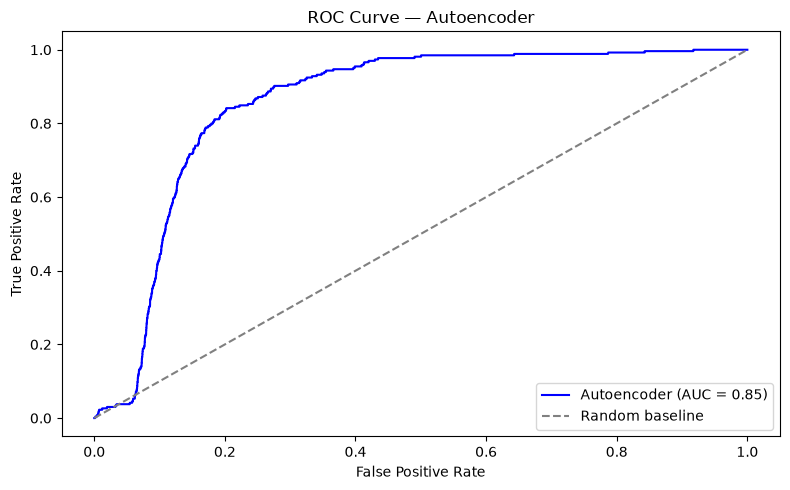

In [12]:
import os
os.makedirs('../../reports', exist_ok=True)

fpr, tpr, _ = roc_curve(y_test, reconstruction_error)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'Autoencoder (AUC = {roc_auc_score(y_test, reconstruction_error):.2f})', color='blue')
plt.plot([0,1],[0,1],'--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Autoencoder')
plt.legend()
plt.tight_layout()
plt.savefig('../../reports/roc_autoencoder.png')
plt.show()

In [13]:
# Save reconstruction errors for comparison notebook
np.save('../../reports/ae_scores.npy', reconstruction_error)
np.save('../../reports/y_test_real.npy', y_test)
print("Scores saved for comparison notebook")

Scores saved for comparison notebook
